In [2]:
# 07 - Model Comparison (with Optuna Hyperparameter Optimization)
# Trains Logistic Regression, Decision Tree, Random Forest, and XGBoost, each
# in two forms:
#   1. Baseline - default hyperparameters
#   2. Tuned - hyperparameters optimized by Optuna, maximizing macro-F1 under
#      repeated stratified cross-validation on the training set

# Why cross-validation instead of a single train/test split for the headline
# numbers: with ~186 usable rows split across 3 tool classes, a single 25%
# holdout is only ~47 rows -- too small and noisy for a fair model comparison.
# So results are reported both ways: a single holdout test (shown here with
# per-model confusion matrices and a train-vs-test score comparison, to check
# for overfitting) and 5-fold cross-validation across the entire labeled
# dataset (the primary, more stable comparison used to pick the winner).

# The best model (by CV macro-F1) is saved for 08_Prediction.ipynb and
# 10_Testing.ipynb, including its tuned hyperparameters so 10_Testing can
# retrain it on the training set only for a clean, unseen-data evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                      cross_val_score, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


In [3]:
# Load prepared data 
ml_dir = 'data/processed/ml_ready'
X_train = pd.read_csv(f'{ml_dir}/X_train.csv')
X_test = pd.read_csv(f'{ml_dir}/X_test.csv')
y_train = pd.read_csv(f'{ml_dir}/y_train.csv').iloc[:, 0]
y_test = pd.read_csv(f'{ml_dir}/y_test.csv').iloc[:, 0]
sample_weight_train = pd.read_csv(f'{ml_dir}/sample_weight_train.csv').iloc[:, 0]

X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, Full: {X_full.shape}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_full_enc = le.transform(y_full)

tuning_cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=3, random_state=42)
eval_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 30


Train: (139, 26), Test: (47, 26), Full: (186, 26)


In [4]:
# Baseline models (default hyperparameters), evaluated on train AND test 
# Evaluating on both lets us see the train-vs-test gap per model (a big gap means overfitting).
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
}

test_results = {}
test_predictions = {}
train_vs_test = {}

for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train_enc, sample_weight=sample_weight_train)
        pred_train = le.inverse_transform(model.predict(X_train))
        pred_test = le.inverse_transform(model.predict(X_test))
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight_train)
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

    key = f'{name} (baseline)'
    test_predictions[key] = pred_test
    test_results[key] = {
        'Accuracy': accuracy_score(y_test, pred_test),
        'Precision (macro)': precision_score(y_test, pred_test, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_test, pred_test, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_test, pred_test, average='macro', zero_division=0),
    }
    train_vs_test[name] = {
        'Train F1 (macro)': f1_score(y_train, pred_train, average='macro', zero_division=0),
        'Test F1 (macro)': f1_score(y_test, pred_test, average='macro', zero_division=0),
    }

pd.DataFrame(test_results).T.round(3)


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Logistic Regression (baseline),0.362,0.379,0.375,0.337
Decision Tree (baseline),0.340,0.273,0.273,0.273
Random Forest (baseline),0.468,0.407,0.394,0.388
XGBoost (baseline),0.426,0.357,0.359,0.358


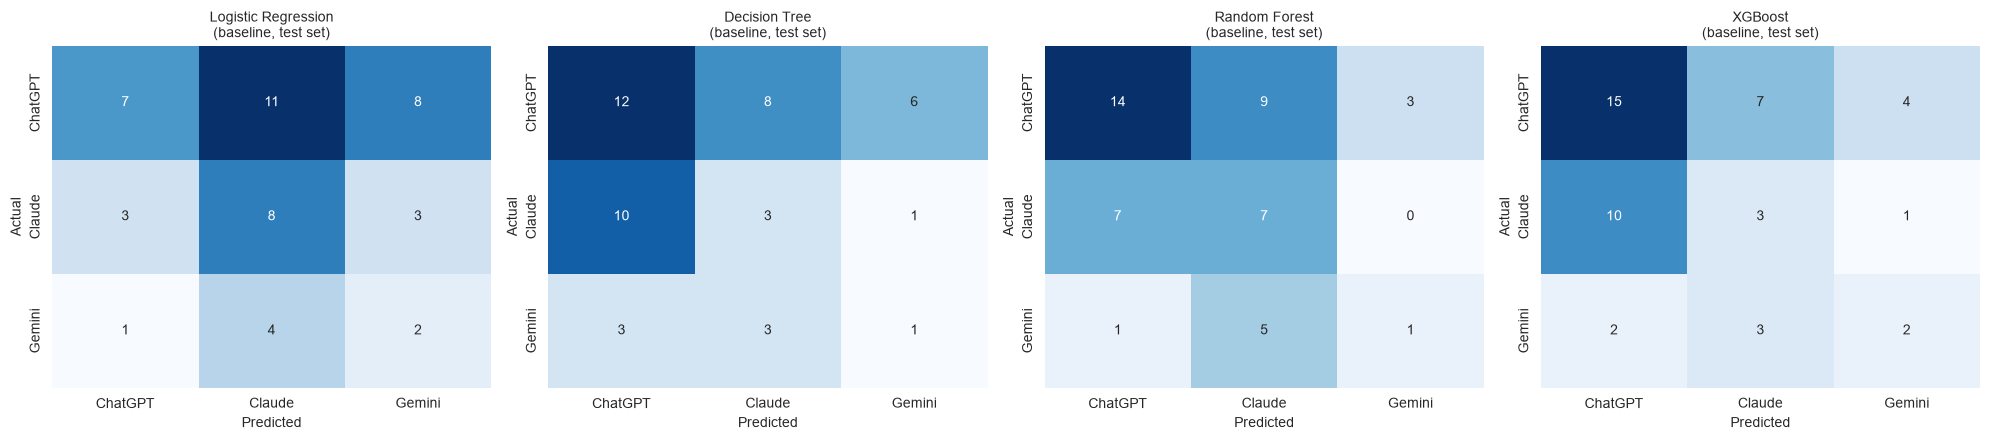

In [5]:
# Diagram: confusion matrix for EACH baseline model on the held-out test set
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
labels = sorted(y_test.unique())
for ax, (name, model) in zip(axes, baseline_models.items()):
    pred = test_predictions[f'{name} (baseline)']
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(f'{name}\n(baseline, test set)', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


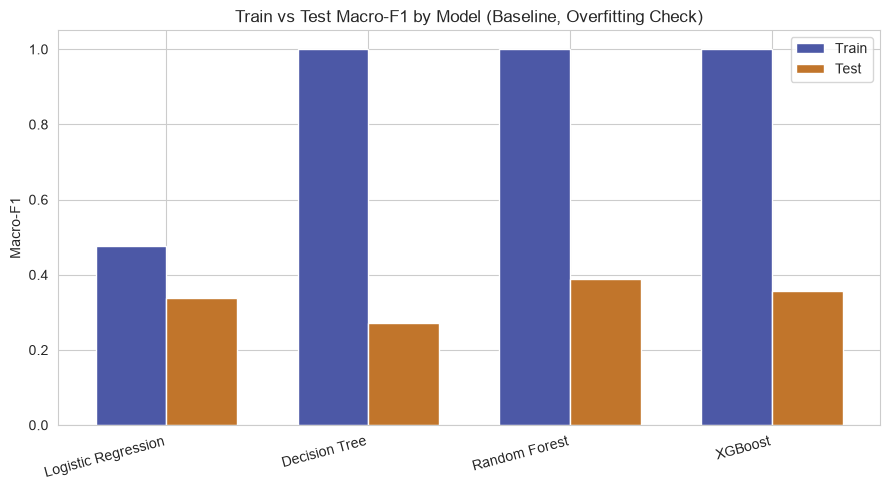

,Train F1 (macro),Test F1 (macro)
Logistic Regression,0.475,0.337
Decision Tree,1.000,0.273
Random Forest,1.000,0.388
XGBoost,1.000,0.358


In [6]:
# Diagram: train vs test macro-F1 per baseline model (overfitting check) 
tvt_df = pd.DataFrame(train_vs_test).T
x = np.arange(len(tvt_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, tvt_df['Train F1 (macro)'], width, label='Train', color='#4C58A6')
ax.bar(x + width/2, tvt_df['Test F1 (macro)'], width, label='Test', color='#C1752B')
ax.set_xticks(x)
ax.set_xticklabels(tvt_df.index, rotation=15, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_title('Train vs Test Macro-F1 by Model (Baseline, Overfitting Check)')
ax.legend()
plt.tight_layout()
plt.show()
tvt_df.round(3)


In [7]:
# Optuna hyperparameter optimization
# Objective: maximize mean macro-F1 across 4-fold x 3-repeat stratified cross-validation on the training set (12 fits per trial) -- more robust than a single CV split, which matters given the small sample size.
def objective_logreg(trial):
    C = trial.suggest_float('C', 0.001, 10, log=True)
    model = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    return cross_val_score(model, X_train, y_train, cv=tuning_cv, scoring='f1_macro', n_jobs=-1).mean()

def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
    }
    model = DecisionTreeClassifier(random_state=42, class_weight='balanced', **params)
    return cross_val_score(model, X_train, y_train, cv=tuning_cv, scoring='f1_macro', n_jobs=-1).mean()

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
    }
    model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
    return cross_val_score(model, X_train, y_train, cv=tuning_cv, scoring='f1_macro', n_jobs=-1).mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, **params)
    return cross_val_score(model, X_train, y_train_enc, cv=tuning_cv, scoring='f1_macro', n_jobs=-1).mean()

objectives = {
    'Logistic Regression': objective_logreg,
    'Decision Tree': objective_dt,
    'Random Forest': objective_rf,
    'XGBoost': objective_xgb,
}

best_params = {}
tuning_cv_scores = {}
for name, objective in objectives.items():
    study = optuna.create_study(direction='maximize', study_name=name)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best_params[name] = study.best_params
    tuning_cv_scores[name] = study.best_value
    print(f"{name}: best tuning-CV macro-F1 = {study.best_value:.3f}, params = {study.best_params}")


Logistic Regression: best tuning-CV macro-F1 = 0.329, params = {'C': 0.01156840818032092}
Decision Tree: best tuning-CV macro-F1 = 0.375, params = {'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1}
Random Forest: best tuning-CV macro-F1 = 0.366, params = {'n_estimators': 216, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 4}
XGBoost: best tuning-CV macro-F1 = 0.384, params = {'n_estimators': 92, 'max_depth': 4, 'learning_rate': 0.08531444738564786, 'subsample': 0.9703276120961613, 'colsample_bytree': 0.8395150058473939}


In [8]:
# Evaluate tuned models the reliable way: 5-fold CV across the full dataset
# Each tuned model, fixed at its best hyperparameters, is evaluated with cross_val_predict across all 186 labeled rows (5 folds), so every row gets
# an out-of-fold prediction and the metrics use the full sample rather than a noisy 47-row slice.
tuned_estimators = {
    'Logistic Regression': lambda p: LogisticRegression(max_iter=1000, class_weight='balanced', **p),
    'Decision Tree': lambda p: DecisionTreeClassifier(random_state=42, class_weight='balanced', **p),
    'Random Forest': lambda p: RandomForestClassifier(random_state=42, class_weight='balanced', **p),
    'XGBoost': lambda p: xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, **p),
}

cv_results = {}
cv_predictions = {}
for name, builder in tuned_estimators.items():
    model = builder(best_params[name])
    if name == 'XGBoost':
        pred_enc = cross_val_predict(model, X_full, y_full_enc, cv=eval_cv, n_jobs=-1)
        pred = le.inverse_transform(pred_enc)
    else:
        pred = cross_val_predict(model, X_full, y_full, cv=eval_cv, n_jobs=-1)
    key = f'{name} (tuned, CV)'
    cv_predictions[key] = pred
    cv_results[key] = {
        'Accuracy': accuracy_score(y_full, pred),
        'Precision (macro)': precision_score(y_full, pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_full, pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_full, pred, average='macro', zero_division=0),
    }

cv_results_df = pd.DataFrame(cv_results).T.round(3)
cv_results_df


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
"Logistic Regression (tuned, CV)",0.403,0.349,0.347,0.342
"Decision Tree (tuned, CV)",0.414,0.334,0.323,0.328
"Random Forest (tuned, CV)",0.425,0.398,0.396,0.381
"XGBoost (tuned, CV)",0.446,0.330,0.331,0.326


In [9]:
# Full comparison table: baseline (holdout) vs tuned (cross-validated) 
baseline_df = pd.DataFrame(test_results).T.round(3)
baseline_df.index = [f'{i} [holdout test, n=47]' for i in baseline_df.index]
cv_df_labeled = cv_results_df.copy()
cv_df_labeled.index = [f'{i} [5-fold CV, n=186]' for i in cv_df_labeled.index]
full_comparison = pd.concat([baseline_df, cv_df_labeled])
full_comparison


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
"Logistic Regression (baseline) [holdout test, n=47]",0.362,0.379,0.375,0.337
"Decision Tree (baseline) [holdout test, n=47]",0.340,0.273,0.273,0.273
"Random Forest (baseline) [holdout test, n=47]",0.468,0.407,0.394,0.388
"XGBoost (baseline) [holdout test, n=47]",0.426,0.357,0.359,0.358
"Logistic Regression (tuned, CV) [5-fold CV, n=186]",0.403,0.349,0.347,0.342
"Decision Tree (tuned, CV) [5-fold CV, n=186]",0.414,0.334,0.323,0.328
"Random Forest (tuned, CV) [5-fold CV, n=186]",0.425,0.398,0.396,0.381
"XGBoost (tuned, CV) [5-fold CV, n=186]",0.446,0.330,0.331,0.326


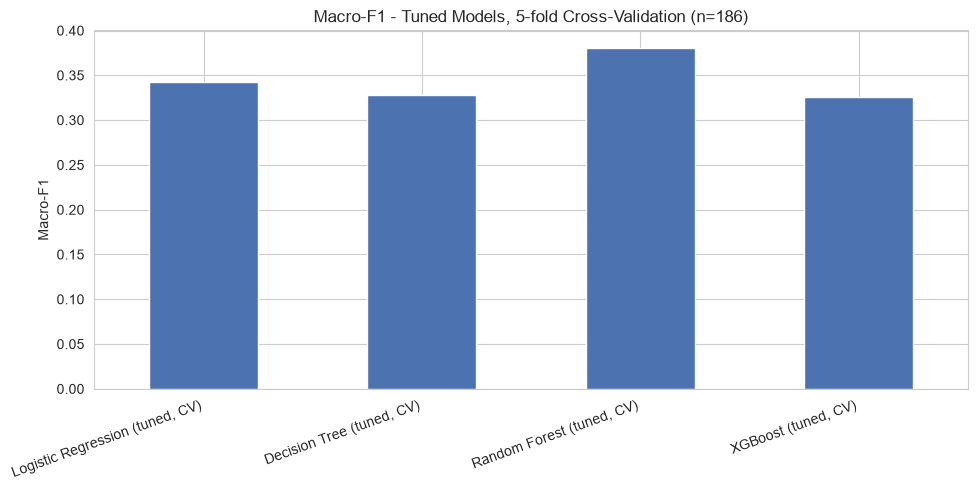

In [10]:
#  Diagram: macro-F1 comparison chart (CV-based, the reliable numbers) 
cv_results_df[['F1 (macro)']].plot(kind='bar', figsize=(10, 5), legend=False, color='#4C72B0')
plt.title('Macro-F1 - Tuned Models, 5-fold Cross-Validation (n=186)')
plt.ylabel('Macro-F1')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


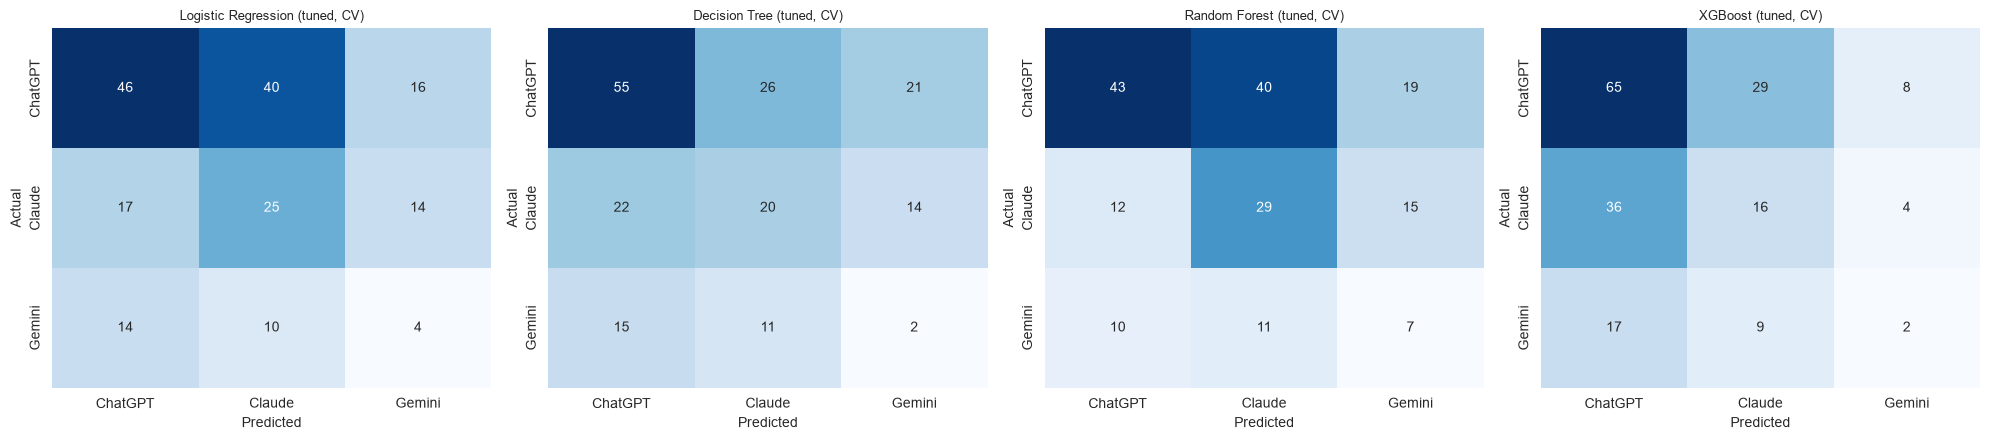

In [11]:
#  Diagram: confusion matrices - tuned models (CV-based, out-of-fold predictions)
fig, axes = plt.subplots(1, len(cv_predictions), figsize=(5 * len(cv_predictions), 4.5))
labels = sorted(y_full.unique())
for ax, name in zip(axes, cv_predictions):
    cm = confusion_matrix(y_full, cv_predictions[name], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [12]:
# Select and save the best overall model (by CV macro-F1) 
best_key = cv_results_df['F1 (macro)'].idxmax()
best_model_name = best_key.replace(' (tuned, CV)', '')
print(f"Best model overall: {best_model_name}")
print()
print(classification_report(y_full, cv_predictions[best_key], zero_division=0))

# Refit the best model on ALL labeled data (train+test) with its tuned
# hyperparameters, so the saved model benefits from every available row
# before making new predictions in 08_Prediction.ipynb.
final_model = tuned_estimators[best_model_name](best_params[best_model_name])
if best_model_name == 'XGBoost':
    final_model.fit(X_full, y_full_enc)
else:
    final_model.fit(X_full, y_full)

os.makedirs('data/processed/models', exist_ok=True)
joblib.dump({
    'model': final_model,
    'model_name': best_model_name,
    'best_params': best_params[best_model_name],   # needed by 10_Testing.ipynb for a clean retrain
    'label_encoder': le if best_model_name == 'XGBoost' else None,
    'feature_columns': X_full.columns.tolist(),
    'cv_macro_f1': cv_results_df.loc[best_key, 'F1 (macro)'],
}, 'data/processed/models/best_model.pkl')

full_comparison.to_csv('data/processed/Model_Comparison_Results.csv')
print("\nSaved: data/processed/models/best_model.pkl")
print("Saved: data/processed/Model_Comparison_Results.csv")


Best model overall: Random Forest

              precision    recall  f1-score   support

     ChatGPT       0.66      0.42      0.51       102
      Claude       0.36      0.52      0.43        56
      Gemini       0.17      0.25      0.20        28

    accuracy                           0.42       186
   macro avg       0.40      0.40      0.38       186
weighted avg       0.50      0.42      0.44       186


Saved: data/processed/models/best_model.pkl
Saved: data/processed/Model_Comparison_Results.csv


In [13]:
# --- Note on results ---
# Optuna tuning improves the CV-based macro-F1 modestly over the untuned defaults, a real but small gain, expected at this sample size (tuning helps a model use available signal more efficiently; it cannot manufacture signal that isn't in the data). 
# The single 47-row holdout numbers can look noisier for some tuned models purely due to which respondents landed inthat split -- this is exactly why the CV-based numbers are the primary result. 
# The clearest path to materially better results is still growing the sample toward the original 250-500 response target.
print("Done.")


Done.
